In [2]:
import pandas as pd

df = pd.read_csv("IMDB_uncleaned.csv")
df.head()
     

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(5000, 2)

In [4]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df['sentiment'].value_counts()

sentiment
negative    2532
positive    2468
Name: count, dtype: int64

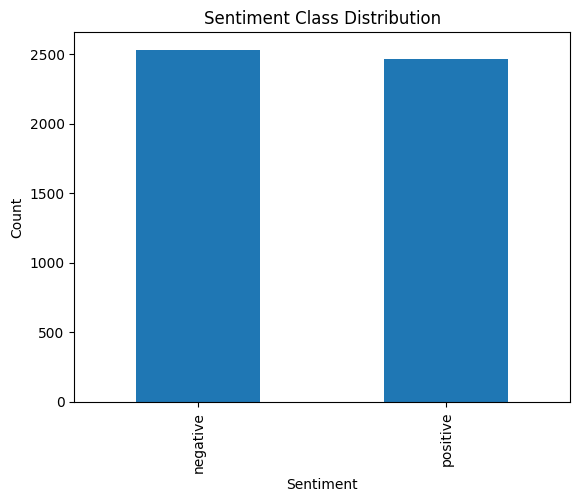

In [10]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()
     

In [8]:
df[df["sentiment"] == "positive"]["review"].iloc[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [9]:
df[df["sentiment"] == "negative"]["review"].iloc[0]

"Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them."

In [15]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = word_tokenize(text)
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hemant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hemant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hemant\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Hemant\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hemant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hemant\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Hemant\AppData\Roaming\nltk_data...


True

In [16]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
     

In [17]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_text(text):
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

In [18]:
df["clean_review"] = df["review"].apply(preprocess_text)

In [19]:

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


In [20]:
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})
df[["clean_review", "sentiment"]].head()

,clean_review,sentiment
0,one reviewer mentioned watching oz episode hoo...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically family little boy jake think zombie ...,0
4,petter mattei love time money visually stunnin...,1


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
     

In [22]:
X = df["clean_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4000
Testing samples: 1000


In [23]:
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW training shape:", X_train_bow.shape)
print("BoW testing shape:", X_test_bow.shape)

BoW training shape: (4000, 5000)
BoW testing shape: (1000, 5000)


In [24]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (4000, 5000)
TF-IDF testing shape: (1000, 5000)


In [25]:
def evaluate_model(model, X_train_vec, X_test_vec, y_train, y_test, model_name, feature_name):
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        "Feature Type": feature_name,
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [26]:
results = []

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Naive Bayes", MultinomialNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=42, max_depth=50))
]

In [27]:
for model_name, model in models:
    results.append(
        evaluate_model(model, X_train_bow, X_test_bow, y_train, y_test, model_name, "BoW")
    )

for model_name, model in models:
    results.append(
        evaluate_model(model, X_train_tfidf, X_test_tfidf, y_train, y_test, model_name, "TF-IDF")
    )

In [28]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df
     

,Feature Type,Model,Accuracy,Precision,Recall,F1 Score
3,TF-IDF,Logistic Regression,0.870,0.869919,0.866397,0.868154
4,TF-IDF,Naive Bayes,0.850,0.872294,0.815789,0.843096
0,BoW,Logistic Regression,0.844,0.840726,0.844130,0.842424
1,BoW,Naive Bayes,0.845,0.867679,0.809717,0.837696
2,BoW,Decision Tree,0.724,0.721545,0.718623,0.720081
5,TF-IDF,Decision Tree,0.676,0.671371,0.674089,0.672727


In [29]:
best_result = results_df.iloc[0]
print("Best Feature Type:", best_result["Feature Type"])
print("Best Model:", best_result["Model"])
print("Best Accuracy:", best_result["Accuracy"])
print("Best Precision:", best_result["Precision"])
print("Best Recall:", best_result["Recall"])
print("Best F1 Score:", best_result["F1 Score"])

Best Feature Type: TF-IDF
Best Model: Logistic Regression
Best Accuracy: 0.87
Best Precision: 0.8699186991869918
Best Recall: 0.8663967611336032
Best F1 Score: 0.8681541582150102


In [30]:
best_model = LogisticRegression(max_iter=1000)
best_model.fit(X_train_tfidf, y_train)

sample_reviews = [
    "This movie was amazing and I loved every scene.",
    "The film was boring, slow, and disappointing."
]

sample_clean = [preprocess_text(review) for review in sample_reviews]
sample_features = tfidf_vectorizer.transform(sample_clean)
sample_predictions = best_model.predict(sample_features)

for review, pred in zip(sample_reviews, sample_predictions):
    label = "Positive" if pred == 1 else "Negative"
    print("Review:", review)
    print("Predicted Sentiment:", label)
    print("-" * 60)

Review: This movie was amazing and I loved every scene.
Predicted Sentiment: Positive
------------------------------------------------------------
Review: The film was boring, slow, and disappointing.
Predicted Sentiment: Negative
------------------------------------------------------------


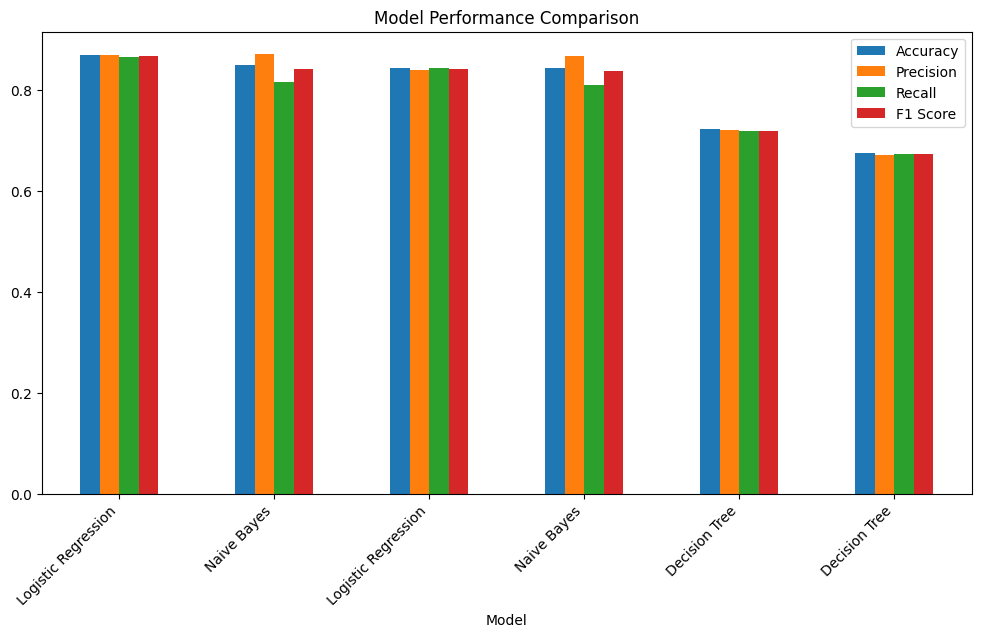

In [31]:
results_df.plot(x="Model", y=["Accuracy", "Precision", "Recall", "F1 Score"], kind="bar", figsize=(12,6))
plt.title("Model Performance Comparison")
plt.xticks(rotation=45, ha='right')
plt.show()